In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor


#load data
df = pd.read_csv("/Users/inayasiddiqui/Documents/Math6243FinalProject/Biodiversity-Predictors/data/processed/marine_data_cleaned.csv")
print(df.head())
print(df.shape)
 


   STUDY_ID  LATITUDE  LONGITUDE  species_richness  total_abundance  \
0       164  37.81020 -122.32300                13            126.0   
1       245  50.85045    3.61936                 9             50.0   
2       245  50.88528    3.69284                 6             49.0   
3       245  50.91131    3.41330                15           1106.0   
4       245  50.91145    3.41317                15            420.0   

   mean_depth  n_samples  n_years  year_start  year_end  ... precip_proxy  \
0    1.000000          3        2        2000      2001  ...  1463.318708   
1   -6.267057          6        2        2009      2010  ...  1133.244839   
2   -6.267057          3        2        2009      2010  ...  1311.765920   
3   -6.267057         15        2        2007      2008  ...  1330.386822   
4   -6.267057         15        2        2007      2008  ...  1041.224731   

   log_area sampling_intensity  depth_category  coastal_proxy  temp_squared  \
0  2.944439                1.5 

In [4]:

target = "log_richness"
 
features_density = [
    'mean_depth',
    'temp_proxy',
    'LATITUDE',
    'precip_proxy',
    'sampling_intensity',
    #'coastal_proxy',
    'temp_squared',
]


data = df[features_density + [target]].dropna()
X = data[features_density].copy()
y = data[target].copy()
 
print("\nFeature matrix shape:", X.shape)


# Scale first so VIF values are comparable, drop highly collinear features
# VIF check, iteratively remove collinear features
def compute_vif(X_scaled, columns):
    vif = pd.DataFrame()
    vif["feature"] = columns
    vif["VIF"] = [
        variance_inflation_factor(X_scaled, i)
        for i in range(X_scaled.shape[1])
    ]
    return vif

remaining = features_density.copy()

while True:
    X_scaled = StandardScaler().fit_transform(X[remaining])
    vif = compute_vif(X_scaled, remaining)
    max_vif = vif["VIF"].max()
    if max_vif <= 10:
        break
    worst = vif.loc[vif["VIF"].idxmax(), "feature"]
    print(f"Dropping '{worst}' with VIF = {max_vif:.1f}")
    remaining.remove(worst)

print("\nFinal features after VIF filtering:")
print(remaining)
print("\nFinal VIF table:")
print(vif.sort_values("VIF", ascending=False).to_string(index=False))

# Update X to only use the surviving features
X = X[remaining]
 
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print("\nTraining set:", X_train.shape)
print("Test set:    ", X_test.shape)


Feature matrix shape: (1619, 6)
Dropping 'temp_proxy' with VIF = 44.7

Final features after VIF filtering:
['mean_depth', 'LATITUDE', 'precip_proxy', 'sampling_intensity', 'temp_squared']

Final VIF table:
           feature      VIF
      temp_squared 2.287776
      precip_proxy 2.221317
          LATITUDE 1.278113
sampling_intensity 1.101217
        mean_depth 1.014542

Training set: (1295, 5)
Test set:     (324, 5)


In [5]:
#Regularized models
def run_regularized_models(X_train, X_test, y_train, y_test, label="Target"):
    results = []
    fitted = {}
 
    # Ridge
    ridge_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Ridge())
    ])
    ridge_param_grid = {"model__alpha": np.logspace(-3, 4, 30)}
    ridge_cv = GridSearchCV(ridge_pipe, ridge_param_grid, cv=5, scoring="r2")
    ridge_cv.fit(X_train, y_train)
    ridge_pred = ridge_cv.predict(X_test)
    results.append({
        "Target":      label,
        "Model":       "Ridge",
        "Best_Params": ridge_cv.best_params_,
        "R2":          r2_score(y_test, ridge_pred),
        "RMSE":        np.sqrt(mean_squared_error(y_test, ridge_pred))
    })
    fitted["Ridge"] = (ridge_cv, ridge_pred)
    
    # Lasso
    lasso_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Lasso(max_iter=100000))
    ])
    lasso_param_grid = {"model__alpha": np.logspace(-4, 2, 30)}
    lasso_cv = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5, scoring="r2")
    lasso_cv.fit(X_train, y_train)
    lasso_pred = lasso_cv.predict(X_test)
    results.append({
        "Target":      label,
        "Model":       "Lasso",
        "Best_Params": lasso_cv.best_params_,
        "R2":          r2_score(y_test, lasso_pred),
        "RMSE":        np.sqrt(mean_squared_error(y_test, lasso_pred))
    })
    fitted["Lasso"] = (lasso_cv, lasso_pred)
 
    # ElasticNet
    elastic_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  ElasticNet(max_iter=100000))
    ])
    elastic_param_grid = {
        "model__alpha":    np.logspace(-4, 2, 20),
        "model__l1_ratio": [0.2, 0.5, 0.8]
    }
    elastic_cv = GridSearchCV(elastic_pipe, elastic_param_grid, cv=5, scoring="r2")
    elastic_cv.fit(X_train, y_train)
    elastic_pred = elastic_cv.predict(X_test)
    results.append({
        "Target":      label,
        "Model":       "ElasticNet",
        "Best_Params": elastic_cv.best_params_,
        "R2":          r2_score(y_test, elastic_pred),
        "RMSE":        np.sqrt(mean_squared_error(y_test, elastic_pred))
    })
    fitted["ElasticNet"] = (elastic_cv, elastic_pred)
 
    print(f"\n--- Results for {label} ---")
    for row in results:
        print(f"{row['Model']}:")
        print("  Best params:", row["Best_Params"])
        print("  R²:  ", round(row["R2"],   4))
        print("  RMSE:", round(row["RMSE"], 4))
 
    return pd.DataFrame(results), fitted
 
 
results_df, fitted_models = run_regularized_models(
    X_train, X_test, y_train, y_test, label="log_richness"
)
print("\nSummary of results:")
print(results_df)


--- Results for log_richness ---
Ridge:
  Best params: {'model__alpha': 67.23357536499334}
  R²:   0.0571
  RMSE: 1.1412
Lasso:
  Best params: {'model__alpha': 0.011721022975334805}
  R²:   0.0563
  RMSE: 1.1417
ElasticNet:
  Best params: {'model__alpha': 0.01623776739188721, 'model__l1_ratio': 0.8}
  R²:   0.0564
  RMSE: 1.1416

Summary of results:
         Target       Model  \
0  log_richness       Ridge   
1  log_richness       Lasso   
2  log_richness  ElasticNet   

                                         Best_Params        R2      RMSE  
0                {'model__alpha': 67.23357536499334}  0.057079  1.141240  
1             {'model__alpha': 0.011721022975334805}  0.056324  1.141697  
2  {'model__alpha': 0.01623776739188721, 'model__...  0.056411  1.141644  


In [6]:

# 10-fold cross-validation  (Pipeline prevents leakage)
kf = KFold(n_splits=10, shuffle=True, random_state=0)
 
def print_cv_results(pipeline, model_name, X_data, y_data, cv):
    cv_mse = cross_val_score(pipeline, X_data, y_data, cv=cv,
                             scoring="neg_mean_squared_error")
    cv_rmse = np.sqrt(-cv_mse)
    cv_r2   = cross_val_score(pipeline, X_data, y_data, cv=cv, scoring="r2")
 
    print(f"\n10-Fold CV — {model_name}")
    print(f"  RMSE per fold: {cv_rmse.round(3)}")
    print(f"  Mean RMSE:     {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")
    print(f"  R²   per fold: {cv_r2.round(3)}")
    print(f"  Mean R²:       {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
 
# re-use best pipelines for CV
print_cv_results(fitted_models["Ridge"][0].best_estimator_,     "Ridge",      X, y, kf)
print_cv_results(fitted_models["Lasso"][0].best_estimator_,     "Lasso",      X, y, kf)
print_cv_results(fitted_models["ElasticNet"][0].best_estimator_,"ElasticNet", X, y, kf)
 
 



10-Fold CV — Ridge
  RMSE per fold: [1.054 1.114 1.064 1.139 1.13  1.111 1.13  1.088 1.16  1.234]
  Mean RMSE:     1.122 ± 0.049
  R²   per fold: [0.07  0.11  0.037 0.045 0.043 0.058 0.103 0.039 0.091 0.023]
  Mean R²:       0.062 ± 0.029

10-Fold CV — Lasso
  RMSE per fold: [1.055 1.114 1.063 1.138 1.13  1.111 1.13  1.087 1.159 1.234]
  Mean RMSE:     1.122 ± 0.049
  R²   per fold: [0.068 0.11  0.039 0.047 0.043 0.059 0.102 0.04  0.092 0.023]
  Mean R²:       0.062 ± 0.028

10-Fold CV — ElasticNet
  RMSE per fold: [1.055 1.114 1.063 1.137 1.13  1.111 1.131 1.087 1.159 1.234]
  Mean RMSE:     1.122 ± 0.049
  R²   per fold: [0.068 0.11  0.039 0.048 0.044 0.059 0.101 0.04  0.091 0.024]
  Mean R²:       0.062 ± 0.028


In [7]:

# coefficients for linear models
def get_coefs(fitted_cv, model_name):
    return fitted_cv.best_estimator_.named_steps["model"].coef_
 
coef_df = pd.DataFrame({
    "Feature":    X.columns,
    "Ridge":      get_coefs(fitted_models["Ridge"][0],      "Ridge"),
    "Lasso":      get_coefs(fitted_models["Lasso"][0],      "Lasso"),
    "ElasticNet": get_coefs(fitted_models["ElasticNet"][0], "ElasticNet"),
})
print("\nTop predictors for log_richness:")
print(
    coef_df
    .sort_values(by="Lasso", key=np.abs, ascending=False)
    .head(20)
    .to_string(index=False)
)


Top predictors for log_richness:
           Feature     Ridge     Lasso  ElasticNet
          LATITUDE -0.306146 -0.308238   -0.304704
      temp_squared -0.152030 -0.161240   -0.158355
        mean_depth  0.148589  0.143946    0.141825
      precip_proxy -0.018223 -0.000651   -0.000069
sampling_intensity  0.002418  0.000000    0.000000


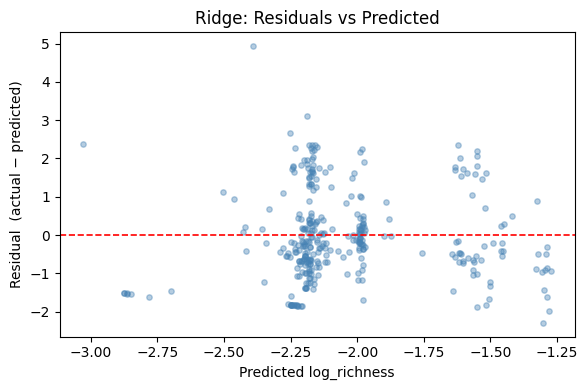

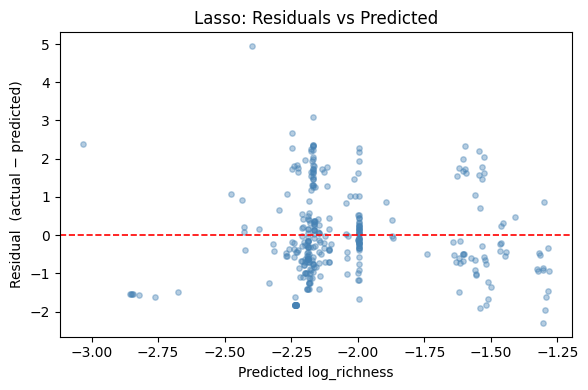

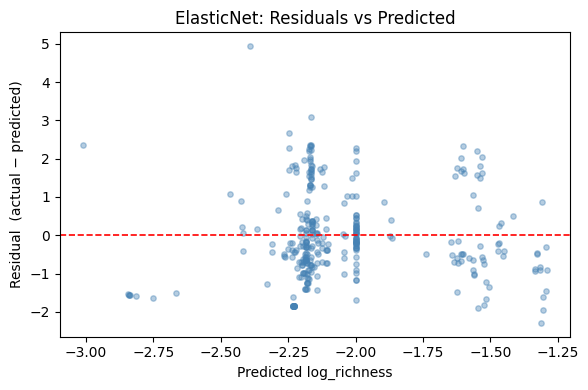

In [8]:
#plots: residuals vs preicted values
def plot_diagnostics(y_test, y_pred, model_name):
    residuals = y_test.values - y_pred

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(y_pred, residuals, alpha=0.4, s=15, color="steelblue")
    ax.axhline(0, color="r", linestyle="--", lw=1.2)
    ax.set_xlabel("Predicted log_richness")
    ax.set_ylabel("Residual  (actual − predicted)")
    ax.set_title(f"{model_name}: Residuals vs Predicted")
    plt.tight_layout()
    plt.show()

# Linear models
for name, (cv_obj, pred) in fitted_models.items():
    plot_diagnostics(y_test, pred, name)



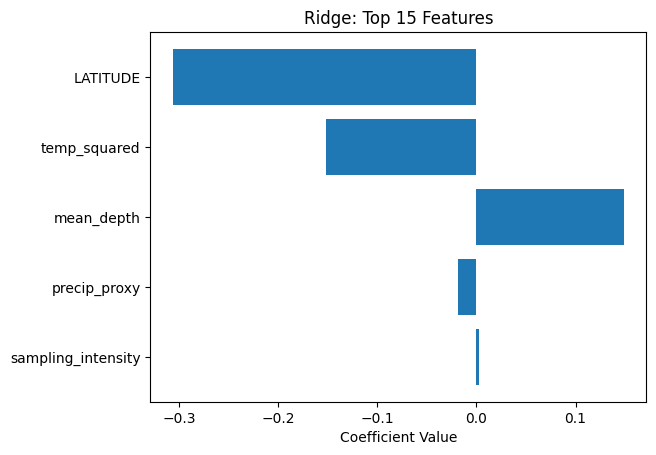

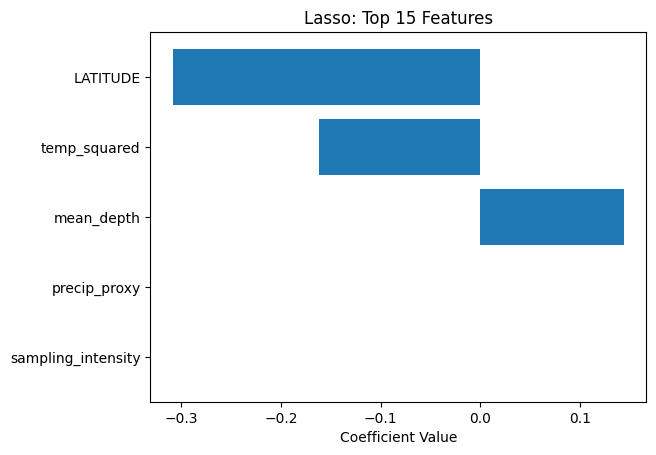

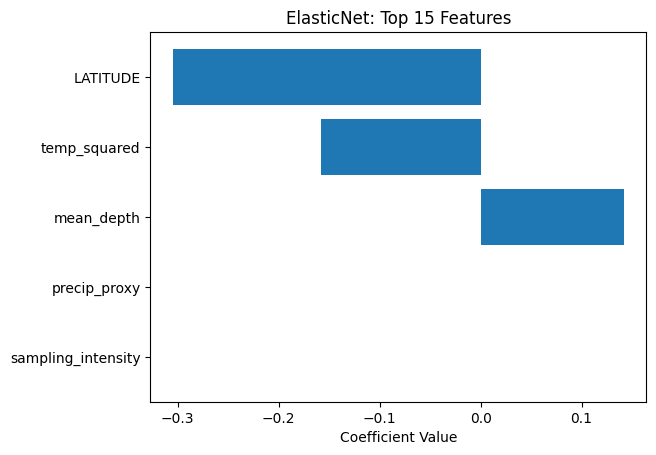

In [9]:
def plot_coefficients(coef_df, model_name, top_n=15):
    coef_sorted = coef_df.copy()
    coef_sorted["abs_val"] = coef_sorted[model_name].abs()
    coef_sorted = coef_sorted.sort_values("abs_val", ascending=False).head(top_n)

    plt.figure()
    plt.barh(coef_sorted["Feature"], coef_sorted[model_name])
    plt.xlabel("Coefficient Value")
    plt.title(f"{model_name}: Top {top_n} Features")
    plt.gca().invert_yaxis()
    plt.show()

plot_coefficients(coef_df, "Ridge")
plot_coefficients(coef_df, "Lasso")
plot_coefficients(coef_df, "ElasticNet")